# Clasificación con SVM

## Pregunta de investigación
¿Puede un modelo SVM clasificar correctamente si un tumor es maligno
o benigno a partir de las características morfológicas del núcleo celular?

## Unidad de análisis
Cada observación corresponde a una muestra de tejido obtenida por
punción aspirativa con aguja fina (FNA).

## Variable objetivo (target)
`target` — variable binaria: 0 = maligno, 1 = benigno
(codificación de `load_breast_cancer` en scikit-learn).

## Advertencia
Este ejercicio tiene fines exclusivamente académicos. Los resultados
**no constituyen un diagnóstico médico** ni deben usarse con fines
clínicos.


In [2]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

bunch = load_breast_cancer(as_frame=True)
X = bunch.data.copy()
y = bunch.target.copy()
print(X.shape)
print(y.value_counts().sort_index())
X.head()

(569, 30)
target
0    212
1    357
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
audit = pd.DataFrame({
    "tipo": X.dtypes.astype(str),
    "ausentes": X.isna().sum(),
    "unicos": X.nunique()
})
print("Duplicados:", X.duplicated().sum())
print("Target dentro de X:", y.name in X.columns)
audit.head(10)

Duplicados: 0
Target dentro de X: False


,tipo,ausentes,unicos
mean radius,float64,0,456
mean texture,float64,0,479
mean perimeter,float64,0,522
mean area,float64,0,539
mean smoothness,float64,0,474
mean compactness,float64,0,537
mean concavity,float64,0,537
mean concave points,float64,0,542
mean symmetry,float64,0,432
mean fractal dimension,float64,0,499


### Resultado de la auditoría

- Los 30 predictores son numéricos (`float64`), sin valores ausentes y sin filas duplicadas.
- El target **no** está dentro de `X`, por lo que no hay fuga directa de la variable objetivo.
- **Balance:** 212 malignos (37.3 %) y 357 benignos (62.7 %). Es un desbalance moderado: por eso se usa `stratify=y` en la división y F1-macro como métrica, en lugar de accuracy.
- No se elimina ninguna fila ni columna, porque la auditoría no encontró motivos para hacerlo.


In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True).round(3))
print(y_test.value_counts(normalize=True).round(3))

(455, 30) (114, 30)
target
1    0.626
0    0.374
Name: proportion, dtype: float64
target
1    0.632
0    0.368
Name: proportion, dtype: float64


In [5]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
print("F1 macro baseline:", f1_score(y_test, dummy_pred, average="macro"))

F1 macro baseline: 0.3870967741935484


In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm = Pipeline([
    ("scale", StandardScaler()),
    ("model", SVC(kernel="rbf", C=1, gamma="scale", probability=True, random_state=42))
])
svm.fit(X_train, y_train)

,steps,"[('scale', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'


              precision    recall  f1-score   support

           0     0.9762    0.9762    0.9762        42
           1     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114

ROC-AUC: 0.995


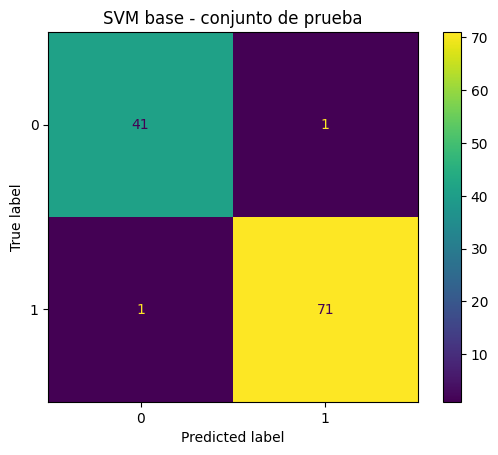

In [7]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score)
import matplotlib.pyplot as plt

pred = svm.predict(X_test)
proba = svm.predict_proba(X_test)[:, 1]
print(classification_report(y_test, pred, digits=4))
print("ROC-AUC:", round(roc_auc_score(y_test, proba), 4))
ConfusionMatrixDisplay.from_predictions(y_test, pred)
plt.title("SVM base - conjunto de prueba")
plt.show()

In [8]:
cm = confusion_matrix(y_test, pred)
print(cm)
print("Malignos clasificados como benignos (real 0, pred 1):", cm[0, 1])
print("Benignos clasificados como malignos (real 1, pred 0):", cm[1, 0])

[[41  1]
 [ 1 71]]
Malignos clasificados como benignos (real 0, pred 1): 1
Benignos clasificados como malignos (real 1, pred 0): 1


### Interpretación de la matriz de confusión (SVM base)

La SVM base acierta 112 de los 114 casos de prueba y comete **2 errores**:

- **1 tumor maligno clasificado como benigno.** En scikit-learn la clase positiva es 1 (benigno), así que técnicamente es un *falso positivo*; en términos clínicos es un **falso negativo de cáncer**.
- **1 tumor benigno clasificado como maligno.** Técnicamente es un *falso negativo*; clínicamente es una **falsa alarma**.

**El error más costoso** es el maligno clasificado como benigno: un cáncer no detectado retrasa el tratamiento y pone en riesgo la vida. La falsa alarma genera ansiedad y pruebas adicionales (biopsia), pero se corrige en el seguimiento. Por eso conviene vigilar el *recall* de la clase 0 (maligno), que aquí es 0.9762.

La matriz se consulta **una sola vez**, como evaluación final. Los hiperparámetros se eligen con validación cruzada sobre el conjunto de entrenamiento, no mirando esta matriz.


In [9]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = GridSearchCV(
    estimator=svm,
    param_grid={
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale", 0.01, 0.1]
    },
    scoring="f1_macro", cv=cv, n_jobs=-1, return_train_score=True
)
search.fit(X_train, y_train)
print(search.best_params_)
print("CV:", round(search.best_score_, 4))

{'model__C': 10, 'model__gamma': 0.01}
CV: 0.9739


In [10]:
cv_results = pd.DataFrame(search.cv_results_)
columns = ["param_model__C", "param_model__gamma",
           "mean_test_score", "std_test_score", "mean_fit_time"]
cv_results[columns].sort_values("mean_test_score", ascending=False).head(9)

,param_model__C,param_model__gamma,mean_test_score,std_test_score,mean_fit_time
7,10.0,0.01,0.973888,0.017677,0.059991
4,1.0,0.01,0.969041,0.016283,0.097840
6,10.0,scale,0.967086,0.013638,0.061881
3,1.0,scale,0.966940,0.015966,0.139433
5,1.0,0.1,0.953323,0.012853,0.136078
1,0.1,0.01,0.942078,0.014347,0.156333
0,0.1,scale,0.937715,0.018035,0.209120
8,10.0,0.1,0.937532,0.023718,0.157905
2,0.1,0.1,0.934135,0.015687,0.257556


In [11]:
best = search.best_estimator_
best_pred = best.predict(X_test)
print(classification_report(y_test, best_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9762    0.9762    0.9762        42
           1     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114



### Comparación: línea base vs. SVM

| Modelo | F1-macro en prueba |
|---|---|
| Línea base (`DummyClassifier`, clase más frecuente) | 0.3871 |
| SVM base (C=1, gamma="scale") | 0.9812 |
| SVM ajustada con GridSearchCV (C=10, gamma=0.01) | 0.9812 |

- La línea base siempre predice "benigno", así que nunca detecta un tumor maligno. Su F1-macro de 0.387 marca el mínimo que cualquier modelo útil debe superar con claridad.
- La SVM supera ampliamente la línea base.
- La mejor configuración en validación cruzada (C=10, gamma=0.01: 0.9739 ± 0.0177) rinde en prueba lo mismo que la SVM base. Las cuatro mejores combinaciones de la tabla difieren en menos de 0.007, mientras que su desviación estándar ronda 0.016. La ganancia de ajustar C y gamma, por tanto, **no es concluyente**. Solo se distinguen con claridad las peores combinaciones (C=0.1 o gamma=0.1), que quedan por debajo de 0.954.
- El conjunto de prueba se usó solo para la evaluación final, no para elegir hiperparámetros.


In [12]:
from pathlib import Path
import os
import joblib

# VS Code ejecuta el notebook desde notebooks/; se trabaja desde la raíz del proyecto
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

Path("reports").mkdir(exist_ok=True)
cv_results[columns].to_csv("reports/svm_cv_results.csv", index=False)
joblib.dump(best, "reports/svm_best.joblib")

['reports/svm_best.joblib']